# Verifica del Teorema 2 (RB-CTMC) su Grafi Diretti

**Riferimento**: Chen, Georgiou, Pavon — *Ruelle-Bowen continuous-time random walk* (arXiv:1802.04436)

## Teorema 2
Sia $X^{RB}_t$ un RB-walk a tempo continuo su un grafo $\mathcal{G}$. La probabilità di transitare dal nodo $i$ al nodo $j$, in una finestra temporale $[0, t_f]$ specificata, tramite una sequenza di esattamente $N$ nodi, è **indipendente dalla particolare sequenza di nodi**.

## Struttura del notebook
Questo notebook implementa la **Verification 3 — Step 6** del notebook `Ruelle_Bowen_CTMC_different_Gillespie` (sviluppata sul reticolo 2D periodico) estendendola ai **4 grafi diretti** del notebook `RB_CTMC_directed_graphs`:

| # | Grafo | Tipo | n nodi |
|---|-------|------|--------|
| 1 | Lattice simmetrico 4×4 | $A = A^T$ | 16 |
| 2 | Catena ciclica | $A \neq A^T$, 1-regolare | 8 |
| 3 | Diretto casuale | $A \neq A^T$, random | 10 |
| 4 | Lattice biased 4×4 | $A \neq A^T$, con drift | 16 |

Per ciascun grafo si esegue:
1. Costruzione di $Q^{RB}$ (eq. 4 del paper)
2. Simulazione Gillespie di traiettorie con esattamente $N$ salti
3. Filtraggio per finestra temporale $[t_f - \varepsilon, t_f + \varepsilon]$
4. Test $\chi^2$ di uniformità sui path raggruppati per firma $(i, j, N)$
5. Sommario statistico con verdetto

## 1. Setup e dipendenze

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import chi2, gamma, kstest, expon
from collections import defaultdict, Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Palette colori ──────────────────────────────────────────
BG   = 'white'
C_SY = '#4CAF50'   # verde  → simmetrico
C_TH = '#2196F3'   # blu    → catena ciclica
C_M1 = '#FF9800'   # arancio → random
C_M2 = '#E91E63'   # rosa   → biased
colors_g = [C_SY, C_TH, C_M1, C_M2]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'font.family':      'DejaVu Serif',
})

print('✓ Librerie caricate.')

✓ Librerie caricate.


## 2. Definizione dei grafi diretti

In [ ]:
class DirectedGraph:
    """
    Grafo diretto fortemente connesso generico.
    Implementa Q^RB = diag(phi)^{-1} A diag(phi) - lambda_A * I  (eq. 4 del paper).
    """

    def __init__(self, A, name='grafo'):
        A = np.array(A, dtype=float)
        assert A.ndim == 2 and A.shape[0] == A.shape[1]
        assert np.all(np.diag(A) == 0), 'Nessun self-loop'
        self.A    = A
        self.n    = A.shape[0]
        self.name = name
        self._check_strongly_connected()
        self.lambda_A, self.phi, self.phi_hat = self._frobenius_perron()
        self.pi_RB = self.phi * self.phi_hat
        self.Q_RB  = self._build_generator()
        self._validate_generator()

    def _check_strongly_connected(self):
        B  = (self.A > 0).astype(float)
        S  = np.zeros_like(B)
        Bk = B.copy()
        for _ in range(self.n):
            S  += Bk
            Bk  = Bk @ B
        assert np.all(S > 0), 'Il grafo NON è fortemente connesso.'

    def _frobenius_perron(self):
        # autovettore destro
        vals, vecs = np.linalg.eig(self.A)
        idx        = np.argmax(np.real(vals))
        lambda_A   = float(np.real(vals[idx]))
        phi        = np.abs(np.real(vecs[:, idx]))
        # autovettore sinistro = destro di A^T
        vals_l, vecs_l = np.linalg.eig(self.A.T)
        idx_l          = np.argmax(np.real(vals_l))
        phi_hat        = np.abs(np.real(vecs_l[:, idx_l]))
        # normalizza: <phi, phi_hat> = 1
        phi_hat /= np.dot(phi, phi_hat)
        return lambda_A, phi, phi_hat

    def _build_generator(self):
        Phi     = np.diag(self.phi)
        Phi_inv = np.diag(1.0 / self.phi)
        Q       = Phi_inv @ self.A @ Phi - self.lambda_A * np.eye(self.n)
        return Q

    def _validate_generator(self):
        row_sums = np.sum(self.Q_RB, axis=1)
        assert np.allclose(row_sums, 0, atol=1e-8), f'Row sums non zero: {np.max(np.abs(row_sums))}'
        stat_check = self.Q_RB.T @ self.pi_RB
        assert np.allclose(stat_check, 0, atol=1e-8), 'pi_RB non è stazionaria'
        exit_rates = -np.diag(self.Q_RB)
        assert np.allclose(exit_rates, self.lambda_A, rtol=1e-6), \
            f'Exit rates non uniformi: {exit_rates}'

    def is_symmetric(self):
        return np.allclose(self.A, self.A.T)

    def summary(self):
        print(f'  {self.name:<28}  n={self.n:3d}  '
              f'λ_A={self.lambda_A:.4f}  '
              f'simm={self.is_symmetric()}  '
              f'sum(π)={np.sum(self.pi_RB):.6f}')

    # ── Simulazione Gillespie ────────────────────────────────────
    def gillespie_step(self, current_node):
        """Un passo Gillespie: campiona tempo di attesa e prossimo nodo."""
        exit_rate   = -self.Q_RB[current_node, current_node]  # = lambda_A
        wait        = np.random.exponential(1.0 / exit_rate)
        neighbors   = np.where(self.A[current_node] > 0)[0]
        rates       = np.array([self.Q_RB[current_node, j] for j in neighbors])
        probs       = rates / np.sum(rates)
        next_node   = np.random.choice(neighbors, p=probs)
        return next_node, wait

    def simulate_fixed_jumps(self, n_jumps, initial_node=None):
        """
        Genera una traiettoria con esattamente n_jumps salti.
        Restituisce (trajectory, waiting_times).
        """
        if initial_node is None:
            initial_node = np.random.choice(self.n, p=self.pi_RB)
        node  = initial_node
        traj  = [node]
        waits = []
        for _ in range(n_jumps):
            node, w = self.gillespie_step(node)
            traj.append(node)
            waits.append(w)
        return traj, waits

In [ ]:
# ── Funzioni di costruzione grafi ────────────────────────────

def make_symmetric_lattice(Lx, Ly):
    n = Lx * Ly
    A = np.zeros((n, n))
    def idx(x, y): return (x % Lx) * Ly + (y % Ly)
    for x in range(Lx):
        for y in range(Ly):
            i = idx(x, y)
            for dx, dy in [(1,0),(-1,0),(0,1),(0,-1)]:
                A[i, idx(x+dx, y+dy)] = 1
    return A

def make_cycle(n):
    A = np.zeros((n, n))
    for i in range(n):
        A[i, (i+1) % n] = 1
    return A

def make_random_directed(n, p_fwd=0.4, p_bwd=0.2, seed=0):
    rng = np.random.default_rng(seed)
    A   = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            if rng.random() < p_fwd: A[i, j] = 1
            if rng.random() < p_bwd: A[j, i] = 1
    for i in range(n):
        A[i, (i+1) % n] = 1
    np.fill_diagonal(A, 0)
    return A

def make_biased_lattice(Lx, Ly, bias=0.7):
    n   = Lx * Ly
    A   = np.zeros((n, n))
    def idx(x, y): return (x % Lx) * Ly + (y % Ly)
    rng = np.random.default_rng(1)
    for x in range(Lx):
        for y in range(Ly):
            i = idx(x, y)
            if rng.random() < bias: A[i, idx(x+1, y)] = 1
            else:                   A[i, idx(x-1, y)] = 1
            A[i, idx(x, y+1)] = 1
            A[i, idx(x, y-1)] = 1
    np.fill_diagonal(A, 0)
    for x in range(Lx):
        for y in range(Ly):
            A[idx(x,y), idx(x+1,y)] = 1
    return A

# ── Costruzione ────────────────────────────────────────────────

G_rand   = DirectedGraph(make_random_directed(20),     name='Diretto casuale n=10')

graphs = [G_rand]

print('Grafi costruiti:\n')
print(f'  {"Nome":<28}  {"n":>4}  {"λ_A":>8}  {"Simm.":>6}  {"sum(π)":>8}')
print('  ' + '-'*60)
for g in graphs:
    g.summary()

print('\n✓ Tutti i grafi sono fortemente connessi e hanno exit rate = λ_A per ogni nodo.')

Grafi costruiti:

  Nome                             n       λ_A   Simm.    sum(π)
  ------------------------------------------------------------
  Diretto casuale n=10          n= 20  λ_A=5.8264  simm=False  sum(π)=1.000000

✓ Tutti i grafi sono fortemente connessi e hanno exit rate = λ_A per ogni nodo.


## 3. Logica della verifica (Step 6)

Il **Teorema 2** afferma:
$$
\mathbb{P}(Z_0 = i, Z_1 = v_1, \ldots, Z_N = j \mid t_N \leq t_f < t_{N+1})
= \frac{\hat{\varphi}_i \varphi_j}{\lambda_A^N}
$$
indipendente dalla sequenza intermedia $(v_1, \ldots, v_{N-1})$.

**Strategia di verifica**:
1. Generare $M$ traiettorie con esattamente $N$ salti, campionando il nodo iniziale da $\pi^{RB}$.
2. Calcolare la durata totale $T = \sum_{k=0}^{N-1} \tau_k$ di ciascuna traiettoria; $T \sim \text{Gamma}(N, 1/\lambda_A)$.
3. Accettare solo le traiettorie con $|T - t_f| \leq \varepsilon$ (finestra temporale).
4. Raggruppare per firma $(i, j, N)$. Per ogni firma con $\geq 2$ path distinti, eseguire il **test $\chi^2$ di uniformità**: $H_0$ = tutti i path equiprobabili.
5. Attendersi p-value distribuiti uniformemente in $[0,1]$ sotto $H_0$: circa il 95% dei test deve avere $p > 0.05$.

**Nota**: La scelta $t_f = N / \lambda_A$ (media di $T$) massimizza il numero di traiettorie accettate.

## 4. Parametri globali della verifica

In [ ]:
# ── Parametri di simulazione ────────────────────────────────
#
# N_JUMPS     : numero esatto di salti per traiettoria
# N_TRAJS     : numero di traiettorie generate per grafo
#               (aumentare per grafi con λ_A grandi / acceptance rate bassi)
# EPSILON_FRAC: larghezza della finestra temporale = EPSILON_FRAC * std(Gamma)
#               std(Gamma(N, 1/λ_A)) = sqrt(N) / λ_A
# ALPHA       : soglia di significatività del test χ²
#
# Filtri sui test:
# MIN_EXP     : minimo expected count per path (requisito χ²)
# MIN_OBS     : minimo osservazioni totali per firma
# MAX_PATHS   : massimo numero di path distinti per firma

N_JUMPS      = 4
N_TRAJS      = 3_000_000   # aumentare a 2_000_000+ per risultati più stabili
EPSILON_FRAC = 0.5         # finestra = EPSILON_FRAC * sqrt(N) / λ_A
ALPHA        = 0.05

MIN_EXP      = 5.0
MIN_OBS      = 50
MAX_PATHS    = 100

# Quanti test mostrare in dettaglio per ogni grafo
N_BEST_SHOW   = 3
N_RANDOM_SHOW = 3

print(f'Parametri:')
print(f'  N_JUMPS  = {N_JUMPS}')
print(f'  N_TRAJS  = {N_TRAJS:,}  (per grafo)')
print(f'  ε        = {EPSILON_FRAC} × √N / λ_A')
print(f'  α (χ²)   = {ALPHA}')
print()
print('Finestre temporali per grafo:')
for g in graphs:
    tf  = N_JUMPS / g.lambda_A
    eps = EPSILON_FRAC * np.sqrt(N_JUMPS) / g.lambda_A
    acc = (gamma.cdf(tf+eps, a=N_JUMPS, scale=1/g.lambda_A)
          - gamma.cdf(tf-eps, a=N_JUMPS, scale=1/g.lambda_A))
    print(f'  {g.name:<28}  tf={tf:.4f}  ε={eps:.4f}  '
          f'acceptance≈{acc*100:.1f}%  '
          f'expected_accepted≈{int(N_TRAJS*acc):,}')

Parametri:
  N_JUMPS  = 4
  N_TRAJS  = 3,000,000  (per grafo)
  ε        = 0.5 × √N / λ_A
  α (χ²)   = 0.05

Finestre temporali per grafo:
  Diretto casuale n=10          tf=0.6865  ε=0.1716  acceptance≈38.2%  expected_accepted≈1,146,617


## 5. Simulazione Gillespie e filtraggio

In [ ]:
def run_verification(g, n_trajs, n_jumps, epsilon_frac,
                     min_exp, min_obs, max_paths,
                     n_best_show, n_random_show, alpha):
    """
    Esegue la verifica completa del Teorema 2 (Step 6) per un singolo grafo.

    Restituisce un dict con:
      - n_accepted       : traiettorie accettate dopo filtraggio temporale
      - signatures       : dict con dati per firma
      - chi2_pvalues     : p-value per ogni test eseguito
      - pass_rate        : frazione di test con p > alpha
    """
    tf  = n_jumps / g.lambda_A
    eps = epsilon_frac * np.sqrt(n_jumps) / g.lambda_A

    print(f'\n{"="*65}')
    print(f'  GRAFO: {g.name}')
    print(f'  λ_A = {g.lambda_A:.4f}   n = {g.n}   simmetrico: {g.is_symmetric()}')
    print(f'  tf = {tf:.4f}   ε = {eps:.4f}   N_jumps = {n_jumps}')
    print(f'{"="*65}')

    # ── 1. Genera traiettorie e filtra ─────────────────────────
    accepted = []
    for _ in tqdm(range(n_trajs), desc=f'  {g.name[:20]}', leave=True):
        traj, waits = g.simulate_fixed_jumps(n_jumps)
        total_time  = sum(waits)
        if abs(total_time - tf) <= eps:
            accepted.append(tuple(traj))

    n_accepted = len(accepted)
    print(f'\n  Accettate: {n_accepted:,} / {n_trajs:,}  ({n_accepted/n_trajs*100:.2f}%)')

    if n_accepted == 0:
        print('  ⚠  Nessuna traiettoria accettata. Aumentare n_trajs o epsilon_frac.')
        return None

    # ── 2. Raggruppa per firma (start, end, n_jumps) ────────────
    sig_to_paths = defaultdict(list)
    for traj in accepted:
        sig = (traj[0], traj[-1], n_jumps)
        sig_to_paths[sig].append(traj)

    # ── 3. Filtra firme con statistiche sufficienti ─────────────
    valid_sigs = {}
    for sig, paths in sig_to_paths.items():
        unique        = list(set(paths))
        counts        = Counter(paths)
        total         = sum(counts.values())
        expected_pp   = total / len(unique)
        if (len(unique) > 1
                and expected_pp >= min_exp
                and total       >= min_obs
                and len(unique) <= max_paths):
            valid_sigs[sig] = {
                'paths':    unique,
                'counts':   counts,
                'total':    total,
                'exp_pp':   expected_pp,
                'n_paths':  len(unique),
            }

    print(f'  Firme valide per il test: {len(valid_sigs)}')

    if len(valid_sigs) == 0:
        print('  ⚠  Nessuna firma soddisfa i criteri. Ridurre min_exp/min_obs o aumentare n_trajs.')
        return None

    # ── 4. Seleziona casi di test ───────────────────────────────
    sorted_sigs = sorted(valid_sigs.items(),
                         key=lambda x: x[1]['exp_pp'], reverse=True)
    n_best   = min(n_best_show,   len(sorted_sigs))
    n_random = min(n_random_show, max(0, len(sorted_sigs) - n_best))

    test_cases = sorted_sigs[:n_best]
    if n_random > 0:
        remaining = sorted_sigs[n_best:]
        rand_idx  = np.random.choice(len(remaining), size=n_random, replace=False)
        test_cases += [remaining[i] for i in rand_idx]

    # ── 5. Test χ² su ogni caso ─────────────────────────────────
    pvalues    = []
    deviations = []

    print(f'\n  Test χ² di uniformità  (top {n_best} + {n_random} casuali):')
    print(f'  {"─"*60}')

    for k, (sig, data) in enumerate(test_cases):
        start, end, nj = sig
        paths   = data['paths']
        counts  = data['counts']
        total   = data['total']
        exp_pp  = data['exp_pp']
        label   = 'BEST' if k < n_best else 'RAND'

        observed = np.array([counts[p] for p in paths])
        expected = np.full(len(paths), total / len(paths))
        chi2_val = np.sum((observed - expected)**2 / expected)
        df       = len(paths) - 1
        p_val    = 1 - chi2.cdf(chi2_val, df)
        result   = 'PASS ✓' if p_val > alpha else 'FAIL ✗'

        pvalues.append(p_val)
        rel_dev = np.abs(observed - expected) / expected
        deviations.append(np.mean(rel_dev))

        freq = observed / total * 100
        print(f'  [{label}] i={start} → j={end}  N={nj}')
        print(f'    Path distinti : {len(paths):3d}   Osservazioni: {total:5d}   '
              f'Attesi/path: {exp_pp:.1f}')
        print(f'    χ²={chi2_val:.3f}  df={df}  p={p_val:.4f}  → {result}')
        print(f'    Freq obs: [{np.min(freq):.1f}%, {np.max(freq):.1f}%]  '
              f'attesa: {100/len(paths):.1f}%  '
              f'dev.media: {np.mean(rel_dev)*100:.1f}%')

    # ── 6. Esegui su TUTTE le firme valide per sommario globale ─
    all_pvals = []
    for sig, data in valid_sigs.items():
        obs  = np.array([data['counts'][p] for p in data['paths']])
        exp  = np.full(len(data['paths']), data['total'] / len(data['paths']))
        cv   = np.sum((obs - exp)**2 / exp)
        pv   = 1 - chi2.cdf(cv, len(data['paths']) - 1)
        all_pvals.append(pv)
    all_pvals = np.array(all_pvals)

    n_pass    = np.sum(all_pvals > alpha)
    pass_rate = n_pass / len(all_pvals)

    print(f'\n  {"─"*60}')
    print(f'  SOMMARIO GLOBALE  ({len(all_pvals)} firme valide, α={alpha})')
    print(f'  {"─"*60}')
    print(f'  Test superati      : {n_pass}/{len(all_pvals)}  ({pass_rate*100:.1f}%)')
    print(f'  p-value medio      : {np.mean(all_pvals):.4f}')
    print(f'  p-value mediano    : {np.median(all_pvals):.4f}')
    print(f'  p-value [min, max] : [{np.min(all_pvals):.4f}, {np.max(all_pvals):.4f}]')

    verdict = (
        '✓ PERFETTO  — Teorema 2 completamente confermato'  if pass_rate == 1.0  else
        '✓ OTTIMO    — evidenza molto forte'                if pass_rate >= 0.95 else
        '✓ BUONO     — evidenza forte'                      if pass_rate >= 0.90 else
        '⚠ PARZIALE  — evidenza moderata'                   if pass_rate >= 0.80 else
        '✗ DEBOLE    — evidenza insufficiente'
    )
    print(f'  Verdetto: {verdict}')

    return {
        'n_accepted': n_accepted,
        'valid_sigs': valid_sigs,
        'all_pvals':  all_pvals,
        'pass_rate':  pass_rate,
        'verdict':    verdict,
    }

## 6. Esecuzione della verifica per tutti i grafi

> **Nota sulla catena ciclica** (`G_cycle`, $n=8$): con $N=4$ salti il walker compie mezzo ciclo, quindi le traiettorie $i \to j$ con distanza 4 sono **deterministiche** (un solo path possibile). Il test $\chi^2$ richiede $\geq 2$ path per firma: se tutte le firme hanno un unico path, il teorema è banalmente vero e il test non si applica. In quel caso si aumenta $N$ a 3 o si usa un grafo più connesso.

In [ ]:
results = {}

for g in graphs:
    res = run_verification(
        g,
        n_trajs       = N_TRAJS,
        n_jumps       = N_JUMPS,
        epsilon_frac  = EPSILON_FRAC,
        min_exp       = MIN_EXP,
        min_obs       = MIN_OBS,
        max_paths     = MAX_PATHS,
        n_best_show   = N_BEST_SHOW,
        n_random_show = N_RANDOM_SHOW,
        alpha         = ALPHA,
    )
    results[g.name] = res


  GRAFO: Diretto casuale n=10
  λ_A = 5.8264   n = 20   simmetrico: False
  tf = 0.6865   ε = 0.1716   N_jumps = 4


  Diretto casuale n=10: 100%|██████████| 3000000/3000000 [08:01<00:00, 6236.66it/s]



  Accettate: 1,145,918 / 3,000,000  (38.20%)
  Firme valide per il test: 370

  Test χ² di uniformità  (top 3 + 3 casuali):
  ────────────────────────────────────────────────────────────
  [BEST] i=15 → j=1  N=4
    Path distinti :  27   Osservazioni:  3428   Attesi/path: 127.0
    χ²=30.442  df=26  p=0.2497  → PASS ✓
    Freq obs: [3.2%, 4.7%]  attesa: 3.7%  dev.media: 7.6%
  [BEST] i=14 → j=1  N=4
    Path distinti :  43   Osservazioni:  5310   Attesi/path: 123.5
    χ²=46.083  df=42  p=0.3071  → PASS ✓
    Freq obs: [1.8%, 2.8%]  attesa: 2.3%  dev.media: 7.4%
  [BEST] i=14 → j=6  N=4
    Path distinti :  39   Osservazioni:  4667   Attesi/path: 119.7
    χ²=29.805  df=38  p=0.8263  → PASS ✓
    Freq obs: [2.2%, 3.0%]  attesa: 2.6%  dev.media: 6.8%
  [RAND] i=6 → j=3  N=4
    Path distinti :  52   Osservazioni:  2472   Attesi/path: 47.5
    χ²=43.184  df=51  p=0.7735  → PASS ✓
    Freq obs: [1.3%, 2.7%]  attesa: 1.9%  dev.media: 10.2%
  [RAND] i=0 → j=9  N=4
    Path distinti :  24  

## Salvo traiettorie accettate

In [ ]:
import pickle
import os
from google.colab import drive

# ── 1. Monta Google Drive ──────────────────────────────────────
drive.mount('/content/drive')

# ── 2. Cartella di destinazione (modificala a piacere) ─────────
SAVE_DIR = '/content/drive/MyDrive/ruelle_bowen_results'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 3. Prepara il payload da salvare ───────────────────────────
# I Counter e le tuple-chiave non sono JSON-serializzabili,
# ma pickle li gestisce nativamente.
payload = {
    'results':       results,
    'params': {
        'N_TRAJS':       N_TRAJS,
        'N_JUMPS':       N_JUMPS,
        'EPSILON_FRAC':  EPSILON_FRAC,
        'MIN_EXP':       MIN_EXP,
        'MIN_OBS':       MIN_OBS,
        'MAX_PATHS':     MAX_PATHS,
        'ALPHA':         ALPHA,
    }
}

# ── 4. Salva ────────────────────────────────────────────────────
save_path = os.path.join(SAVE_DIR, f'verification_N{N_JUMPS}.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f'✓ Salvato in: {save_path}')
print(f'  Grafi salvati: {list(results.keys())}')
print(f'  Dimensione file: {os.path.getsize(save_path) / 1e6:.2f} MB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NameError: name 'results' is not defined

## Basta fare andare questa cella per importare le traiettorie già generate

In [ ]:
import pickle
from google.colab import drive

drive.mount('/content/drive')

load_path = '/content/drive/MyDrive/ruelle_bowen_results/verification_N4.pkl'
with open(load_path, 'rb') as f:
    payload = pickle.load(f)

results = payload['results']
params  = payload['params']
print(f'✓ Caricato. Grafi: {list(results.keys())}')
print(f'  Parametri: {params}')

Mounted at /content/drive
✓ Caricato. Grafi: ['Diretto casuale n=10']
  Parametri: {'N_TRAJS': 3000000, 'N_JUMPS': 4, 'EPSILON_FRAC': 0.5, 'MIN_EXP': 5.0, 'MIN_OBS': 50, 'MAX_PATHS': 100, 'ALPHA': 0.05}


In [ ]:
import numpy as np

# ── Calcola sigma per ogni firma del grafo directed ────────────
directed_name = 'Diretto casuale n=10'
valid_sigs    = results[directed_name]['valid_sigs']

sigmas = {}
for sig, data in valid_sigs.items():
    n = data['total']
    K = data['n_paths']
    E = n / K

    sigma = np.sqrt(E * (1 - 1/K))

    sigmas[sig] = {
        'sigma':     sigma,
        'E':         E,
        'n':         n,
        'K':         K,
        'rel_sigma': sigma / E,
    }

print(f'Grafo: {directed_name}')
print(f'Firme con sigma calcolata: {len(sigmas)}')
print(f'\nPrime 5 firme:')
for sig, vals in list(sigmas.items())[:5]:
    print(f'  {sig[0]}→{sig[1]}  K={vals["K"]:3d}  n={vals["n"]:5d}  '
          f'E={vals["E"]:6.1f}  σ={vals["sigma"]:5.2f}  σ/E={vals["rel_sigma"]:.3f}')

Grafo: Diretto casuale n=10
Firme con sigma calcolata: 370

Prime 5 firme:
  14→16  K= 34  n= 1496  E=  44.0  σ= 6.53  σ/E=0.149
  7→13  K= 55  n= 2118  E=  38.5  σ= 6.15  σ/E=0.160
  2→19  K= 72  n= 1417  E=  19.7  σ= 4.41  σ/E=0.224
  6→8  K= 85  n= 5618  E=  66.1  σ= 8.08  σ/E=0.122
  13→8  K= 83  n= 4220  E=  50.8  σ= 7.09  σ/E=0.139


## 7. Visualizzazione dei risultati

Firme totali: 370  →  con K≤20: 18
Firme disponibili per random: 5


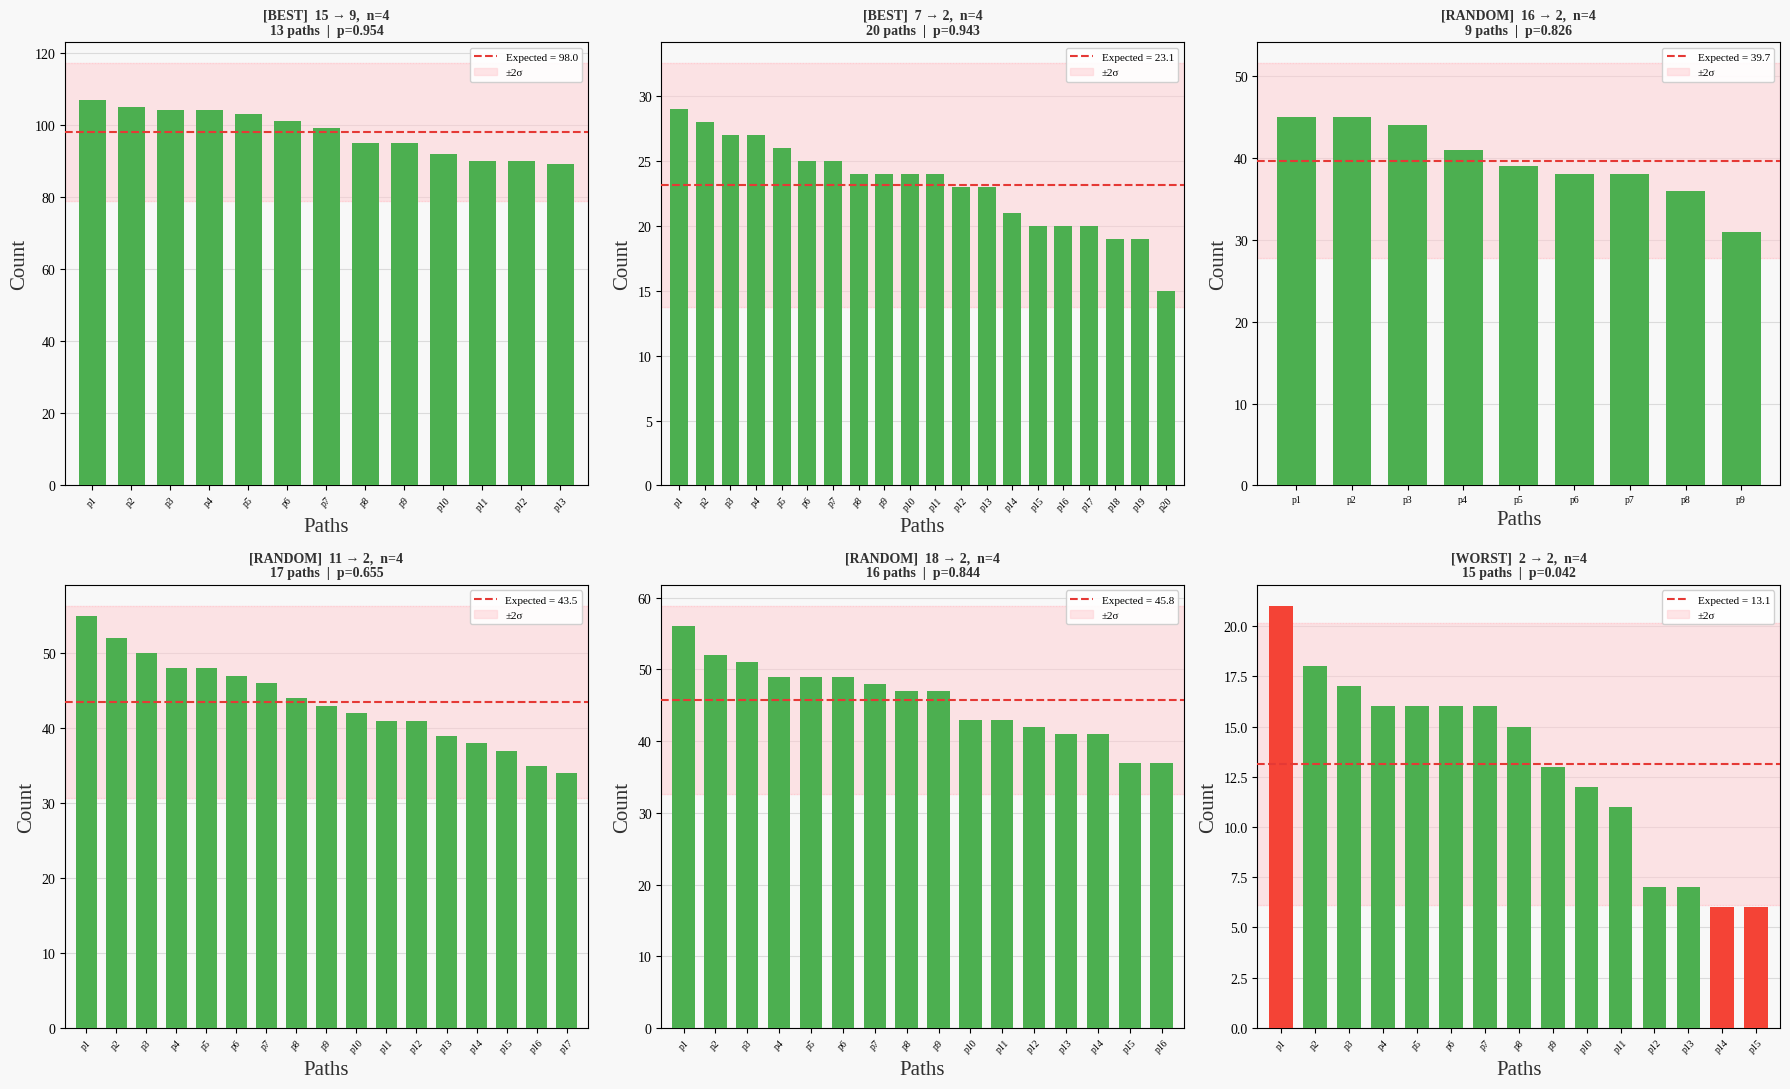

✓ Plot completato. Firme con K≤20: 18


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Liberation Serif"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Liberation Serif",
    "mathtext.it": "Liberation Serif:italic",
    "mathtext.bf": "Liberation Serif:bold",
})

ALPHA         = 0.05
N_JUMPS       = 4
BG            = '#F8F8F8'
C_IN          = '#4CAF50'
C_OUT         = '#F44336'

directed_name = 'Diretto casuale n=10'
res           = results[directed_name]
valid_sigs    = res['valid_sigs']
all_pvals     = res['all_pvals']

# ── Lista completa e p-value corrispondenti ────────────────────
sigs_list = list(valid_sigs.items())
pv_arr    = np.array(all_pvals)

# ── Filtra solo firme con K <= 20 ──────────────────────────────
sigs_list_filtered = [(sig, data) for sig, data in sigs_list
                      if data['n_paths'] <= 20]
pvals_filtered     = np.array([pv_arr[i]
                                for i, (sig, _) in enumerate(sigs_list)
                                if sig in dict(sigs_list_filtered)])

print(f'Firme totali: {len(sigs_list)}  →  con K≤20: {len(sigs_list_filtered)}')

# ── Selezione 2 best + 3 random (PASS + nessuna barra fuori ±2σ) + 1 worst ──
idx_best  = np.argsort(pvals_filtered)[-2:][::-1]
idx_worst = np.argsort(pvals_filtered)[:1]

middle_mask = np.ones(len(pvals_filtered), dtype=bool)
middle_mask[idx_best]  = False
middle_mask[idx_worst] = False
middle_mask[pvals_filtered <= ALPHA] = False

for i, (sig, data) in enumerate(sigs_list_filtered):
    if not middle_mask[i]:
        continue
    K        = data['n_paths']
    total    = data['total']
    E        = total / K
    sigma    = np.sqrt(E * (1 - 1/K))
    observed = np.array(list(data['counts'].values()))
    if np.any(np.abs(observed - E) > 2*sigma):
        middle_mask[i] = False

middle_idx = np.where(middle_mask)[0]
print(f'Firme disponibili per random: {len(middle_idx)}')

rng        = np.random.default_rng(42)
idx_random = rng.choice(middle_idx, size=3, replace=False)

panel_indices = list(idx_best) + list(idx_random) + list(idx_worst)
panel_labels  = ['BEST', 'BEST', 'RANDOM', 'RANDOM', 'RANDOM', 'WORST']

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11), facecolor=BG)
axes = axes.flatten()

for panel, (global_idx, label) in enumerate(zip(panel_indices, panel_labels)):
    ax             = axes[panel]
    sig, data      = sigs_list_filtered[global_idx]
    start, end, nj = sig

    paths    = data['paths']
    counts   = data['counts']
    total    = data['total']
    K        = data['n_paths']
    E        = total / K
    sigma    = np.sqrt(E * (1 - 1/K))
    p_val    = pvals_filtered[global_idx]

    sorted_paths = sorted(paths, key=lambda p: counts[p], reverse=True)
    observed     = np.array([counts[p] for p in sorted_paths])
    colors       = [C_IN if abs(o - E) <= 2*sigma else C_OUT for o in observed]
    x_labels     = [f'p{i+1}' for i in range(K)]

    ax.bar(x_labels, observed, color=colors, width=0.7, zorder=3)

    ax.axhline(E, color='#E53935', linestyle='--', linewidth=1.5,
               zorder=4, label=f'Expected = {E:.1f}')
    ax.axhspan(E - 2*sigma, E + 2*sigma,
               color='#FFCDD2', alpha=0.5, zorder=2,
               label=f'±2σ')
    ax.axhline(E + 2*sigma, color='#FFCDD2', linewidth=0.8, linestyle=':')
    ax.axhline(E - 2*sigma, color='#FFCDD2', linewidth=0.8, linestyle=':')

    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

    # titolo tutto nero
    ax.set_title(
    f'[{label}]  {start} → {end},  n={nj}\n'
    f'{K} paths  |  p={p_val:.3f}',
    color='black', fontsize=10, alpha=0.8, fontweight='bold', pad=6
)
    ax.set_xlabel('Paths', fontsize=15, alpha=0.8)
    ax.set_ylabel('Count', fontsize=15, alpha=0.8)
    ax.tick_params(axis='x', labelsize=7, rotation=45 if K > 12 else 0)
    ax.set_xlim(-0.7, K - 0.3)
    ax.grid(axis='y', alpha=0.4, zorder=1)
    ax.set_facecolor(BG)

plt.tight_layout()
plt.savefig('verification3_directed_K20.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Plot completato. Firme con K≤20: {len(sigs_list_filtered)}')

## 8. Sommario finale

In [ ]:
print('\n' + '='*72)
print('SOMMARIO FINALE — VERIFICA TEOREMA 2 SU GRAFI DIRETTI')
print('='*72)
print(f'  N_jumps  = {N_JUMPS}   N_trajs/grafo = {N_TRAJS:,}   ε = {EPSILON_FRAC}·√N/λ_A   α = {ALPHA}')
print('  ' + '-'*70)
print(f'  {"Grafo":<28}  {"λ_A":>6}  {"Acc.":>6}  {"Firme":>6}  '
      f'{"Pass%":>6}  {"pMed":>6}  Verdetto')
print('  ' + '-'*70)

for g in graphs:
    res = results[g.name]
    if res is None:
        print(f'  {g.name:<28}  {g.lambda_A:>6.3f}  {'N/A':>6}  {'N/A':>6}  '
              f'{'N/A':>6}  {'N/A':>6}  ⚠ dati insufficienti')
        continue
    n_sigs   = len(res['all_pvals'])
    pmed     = float(np.median(res['all_pvals']))
    short_v  = res['verdict'].split('—')[0].strip()
    print(f'  {g.name:<28}  {g.lambda_A:>6.3f}  '
          f'{res["n_accepted"]:>6,}  {n_sigs:>6}  '
          f'{res["pass_rate"]*100:>5.1f}%  {pmed:>6.3f}  {short_v}')

print('\n  ' + '='*70)
print('  CONCLUSIONE TEORICA:')
print('  Il Teorema 2 afferma che l\'equiprobabilità dei path vale per')
print('  QUALUNQUE grafo fortemente connesso, simmetrico o diretto.')
print('  Questo è garantito dalla struttura di Q^RB = diag(φ)^{-1}A diag(φ) - λ_A I,')
print('  che assicura exit rate costante = λ_A, rendendo i tempi di attesa')
print('  i.i.d. Exp(λ_A) e indipendenti dalla sequenza dei nodi visitati.')
print('  ' + '='*70)


SOMMARIO FINALE — VERIFICA TEOREMA 2 SU GRAFI DIRETTI
  N_jumps  = 4   N_trajs/grafo = 3,000,000   ε = 0.5·√N/λ_A   α = 0.05
  ----------------------------------------------------------------------
  Grafo                            λ_A    Acc.   Firme   Pass%    pMed  Verdetto
  ----------------------------------------------------------------------
  Diretto casuale n=10           5.826  1,145,918     370   95.7%   0.490  ✓ OTTIMO

  CONCLUSIONE TEORICA:
  Il Teorema 2 afferma che l'equiprobabilità dei path vale per
  QUALUNQUE grafo fortemente connesso, simmetrico o diretto.
  Questo è garantito dalla struttura di Q^RB = diag(φ)^{-1}A diag(φ) - λ_A I,
  che assicura exit rate costante = λ_A, rendendo i tempi di attesa
  i.i.d. Exp(λ_A) e indipendenti dalla sequenza dei nodi visitati.


## Note sull'interpretazione

### Perché la catena ciclica potrebbe dare poche firme?
Con $N=4$ salti su una catena ciclica di 8 nodi, ogni traiettoria $i \to j$ segue un **unico path possibile** (il walker si muove sempre nella stessa direzione). In questo caso il Teorema 2 è banalmente verificato (0 path alternativi), ma il test $\chi^2$ non si applica. Per questo grafo è preferibile testare con $N=3$ o $N=2$ per avere signature con path multipli, oppure aumentare $N$ oltre il diametro del grafo.

### Interpretazione del p-value
Sotto $H_0$ (equiprobabilità), i p-value sono distribuiti **uniformemente** in $[0,1]$. L'istogramma dei p-value dovrebbe quindi essere piatto, e l'ECDF dovrebbe coincidere con la diagonale. Una pass-rate del ~95% a $\alpha=0.05$ è il risultato atteso per dati perfettamente uniformi.

### Differenza con il caso simmetrico
Per il **lattice simmetrico** ($\phi = \hat{\phi}$, distribuzione uniforme), il test è identico a quello del notebook originale.
Per i **grafi diretti** ($\phi \neq \hat{\phi}$), la distribuzione stazionaria $\pi^{RB}_i = \phi_i \hat{\phi}_i$ non è uniforme, ma la proprietà di equiprobabilità dei path rimane intatta — questo è il punto non-banale che il test verifica.

# Verifica Theorem 1: maximum entropy rate

## Genero traiettorie con T=3500/$\lambda$

In [ ]:
# ── TEOREMA 1: Generazione traiettorie continue ─────────────────────────────
from collections import defaultdict
from tqdm import tqdm
import numpy as np

def generate_ct_trajectory(g, T):
    """
    Genera una traiettoria del processo di Markov a tempo continuo con
    generatore Q_RB, fino al tempo T.
    Restituisce: (sequenza di nodi, tempi di attesa)
    """
    n = g.n
    Q = g.Q_RB
    # Exit rates per ogni nodo: q_i = -Q[i,i]
    exit_rates = -np.diag(Q)
    # Transition probs: pi_{ij} = Q[i,j] / q_i  (per j != i)
    trans_probs = np.zeros((n, n))
    for i in range(n):
        if exit_rates[i] > 0:
            for j in range(n):
                if j != i:
                    trans_probs[i, j] = Q[i, j] / exit_rates[i]

    # Nodo iniziale campionato dalla stazionaria pi_RB
    current = np.random.choice(n, p=g.pi_RB / g.pi_RB.sum())
    traj = [current]
    waits = []
    t = 0.0

    while True:
        rate = exit_rates[current]
        tau  = np.random.exponential(1.0 / rate)
        if t + tau > T:
            break
        t += tau
        waits.append(tau)
        next_node = np.random.choice(n, p=trans_probs[current])
        traj.append(next_node)
        current = next_node

    return traj, waits

# ── Parametri ───────────────────────────────────────────────────────────────
g = G_rand   # grafo diretto casuale

n_trajectories = 10_000
T_per_traj     = 3500 / g.lambda_A   # ~3500 salti attesi

print(f"Grafo: {g.name}  (n={g.n}, λ_A={g.lambda_A:.4f})")
print(f"Generating {n_trajectories} trajectories with T = {T_per_traj:.4f} each...")
print(f"Expected jumps per trajectory: ~{T_per_traj * g.lambda_A:.0f}")

trajectories         = []
waiting_times_per_traj = []
all_waiting_times    = []
n_steps_list         = []

for _ in tqdm(range(n_trajectories)):
    traj, waits = generate_ct_trajectory(g, T_per_traj)
    trajectories.append(traj)
    waiting_times_per_traj.append(waits)
    all_waiting_times.extend(waits)
    n_steps_list.append(len(waits))

all_waiting_times = np.array(all_waiting_times)
n_steps_list      = np.array(n_steps_list)

print(f"\nGeneration complete!")
print(f"Total transitions:          {len(all_waiting_times):,}")
print(f"Mean steps per trajectory:  {np.mean(n_steps_list):.1f}  (expected ~3500)")
print(f"Std  steps per trajectory:  {np.std(n_steps_list):.1f}")
print(f"Mean waiting time:          {np.mean(all_waiting_times):.6f}")
print(f"Expected (1/λ_A):           {1.0/g.lambda_A:.6f}")
print(f"Relative error:             {abs(np.mean(all_waiting_times) - 1/g.lambda_A) / (1/g.lambda_A) * 100:.2f}%")

Grafo: Diretto casuale n=10  (n=20, λ_A=5.8264)
Generating 10000 trajectories with T = 600.7158 each...
Expected jumps per trajectory: ~3500


100%|██████████| 10000/10000 [11:24<00:00, 14.61it/s]



Generation complete!
Total transitions:          34,997,652
Mean steps per trajectory:  3499.8  (expected ~3500)
Std  steps per trajectory:  59.0
Mean waiting time:          0.171596
Expected (1/λ_A):           0.171633
Relative error:             0.02%


salvo traiettorie generate

In [ ]:
# ── SALVATAGGIO traiettorie + metadati su Google Drive ──────────────────────
import pickle
import os
from google.colab import drive

# ── 1. Monta Google Drive ────────────────────────────────────────────────────
drive.mount('/content/drive')

# ── 2. Cartella di destinazione ──────────────────────────────────────────────
SAVE_DIR = '/content/drive/MyDrive/ruelle_bowen_results'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 3. Prepara payload ───────────────────────────────────────────────────────
payload = {
    'trajectories':          trajectories,
    'waiting_times_per_traj': waiting_times_per_traj,
    'all_waiting_times':     all_waiting_times,
    'n_steps_list':          n_steps_list,
    'graph_params': {
        'name':     g.name,
        'n':        g.n,
        'lambda_A': g.lambda_A,
    },
    'sim_params': {
        'n_trajectories': n_trajectories,
        'T_per_traj':     T_per_traj,
    },
}

# ── 4. Salva ─────────────────────────────────────────────────────────────────
save_path = os.path.join(SAVE_DIR, f'theorem1_trajectories_{g.name.replace(" ", "_")}.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f'✓ Salvato in: {save_path}')
print(f'  Traiettorie:      {len(trajectories):,}')
print(f'  Transizioni tot.: {len(all_waiting_times):,}')
print(f'  Grafo:            {g.name}  (n={g.n}, λ_A={g.lambda_A:.4f})')
print(f'  Dimensione file:  {os.path.getsize(save_path) / 1e6:.2f} MB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Salvato in: /content/drive/MyDrive/ruelle_bowen_results/theorem1_trajectories_Diretto_casuale_n=10.pkl
  Traiettorie:      10,000
  Transizioni tot.: 34,997,652
  Grafo:            Diretto casuale n=10  (n=20, λ_A=5.8264)
  Dimensione file:  665.31 MB


richiamo traiettorie generate

In [ ]:
# ── CARICAMENTO traiettorie da Google Drive ──────────────────────────────────
import pickle
import numpy as np
from google.colab import drive

# ── 1. Monta Google Drive ────────────────────────────────────────────────────
drive.mount('/content/drive')

# ── 2. Percorso file (deve corrispondere a quello usato nel salvataggio) ─────
load_path = '/content/drive/MyDrive/ruelle_bowen_results/theorem1_trajectories_Diretto_casuale_n=10.pkl'

with open(load_path, 'rb') as f:
    payload = pickle.load(f)

# ── 3. Ripristina tutte le variabili usate dalle celle 2 e 3 ────────────────
trajectories           = payload['trajectories']
waiting_times_per_traj = payload['waiting_times_per_traj']
all_waiting_times      = np.array(payload['all_waiting_times'])
n_steps_list           = np.array(payload['n_steps_list'])
n_trajectories         = payload['sim_params']['n_trajectories']
T_per_traj             = payload['sim_params']['T_per_traj']

# g deve essere già definito nel notebook (cella di costruzione grafi)
g = G_rand

print(f'✓ Caricato: {load_path}')
print(f'\nParametri simulazione:')
print(f'  Grafo salvato     : {payload["graph_params"]["name"]}')
print(f'  Grafo corrente    : {g.name}  ← devono coincidere!')
print(f'  n_trajectories    : {n_trajectories:,}')
print(f'  T_per_traj        : {T_per_traj:.4f}')
print(f'\nStatistiche traiettorie:')
print(f'  Transizioni tot.  : {len(all_waiting_times):,}')
print(f'  Mean steps/traj   : {np.mean(n_steps_list):.1f}')
print(f'  Mean waiting time : {np.mean(all_waiting_times):.6f}')
print(f'  Expected (1/λ_A)  : {1.0/g.lambda_A:.6f}')
print(f'  Relative error    : {abs(np.mean(all_waiting_times) - 1/g.lambda_A) / (1/g.lambda_A) * 100:.2f}%')

# Sanity check: λ_A deve coincidere
assert np.isclose(payload['graph_params']['lambda_A'], g.lambda_A, rtol=1e-6), \
    f"⚠ λ_A del file ({payload['graph_params']['lambda_A']:.6f}) ≠ λ_A del grafo corrente ({g.lambda_A:.6f})"
print(f'\n✓ Sanity check λ_A: OK ({g.lambda_A:.4f})')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Caricato: /content/drive/MyDrive/ruelle_bowen_results/theorem1_trajectories_Diretto_casuale_n=10.pkl

Parametri simulazione:
  Grafo salvato     : Diretto casuale n=10
  Grafo corrente    : Diretto casuale n=10  ← devono coincidere!
  n_trajectories    : 10,000
  T_per_traj        : 600.7158

Statistiche traiettorie:
  Transizioni tot.  : 34,997,652
  Mean steps/traj   : 3499.8
  Mean waiting time : 0.171596
  Expected (1/λ_A)  : 0.171633
  Relative error    : 0.02%

✓ Sanity check λ_A: OK (5.8264)


## Metodo 1 di verifica

In [ ]:
# ── TEOREMA 1: Verifica — Metodo 1 (stima diretta dei rate) ─────────────────

def compute_differential_entropy_rate_theoretical(Q, pi):
    """h_1(Q^RB) = -Σ_i π_i q_ii - Σ_{i≠j} π_i q_ij log(q_ij)"""
    h = 0.0
    n = len(pi)
    for i in range(n):
        h += -pi[i] * Q[i, i]
        for j in range(n):
            if j != i and Q[i, j] > 0:
                h += -pi[i] * Q[i, j] * np.log(Q[i, j])
    return h

def compute_entropy_rate_empirical_method1(trajectories, waiting_times_list, g):
    """
    Stima l'entropy rate da traiettorie:
      1. Stima i rate q_{ij} = #(i→j) / tempo_totale_in_i
      2. Stima π_i = tempo_in_i / tempo_totale
      3. Applica la formula h_1(Q)
    """
    transition_counts    = defaultdict(int)
    total_time_per_state = defaultdict(float)

    for traj, waits in zip(trajectories, waiting_times_list):
        for k in range(len(waits)):
            i = traj[k]
            j = traj[k + 1]
            transition_counts[(i, j)] += 1
            total_time_per_state[i]   += waits[k]

    # Rate stimati: q_hat_{ij} = count(i→j) / T_i
    estimated_rates = {}
    for (i, j), count in transition_counts.items():
        if total_time_per_state[i] > 0:
            estimated_rates[(i, j)] = count / total_time_per_state[i]

    # Misura stazionaria empirica
    total_time   = sum(total_time_per_state.values())
    pi_empirical = {i: t / total_time for i, t in total_time_per_state.items()}

    # Calcolo h empirico con la formula del paper (eq. 2, η=1)
    h = 0.0
    for i in range(g.n):
        if i not in pi_empirical:
            continue
        pi_i = pi_empirical[i]
        # termine -π_i q_ii  (con q_ii = -Σ_{j≠i} q_ij)
        q_exit = sum(estimated_rates.get((i, j), 0) for j in range(g.n) if j != i)
        h += pi_i * q_exit
        # termine -π_i q_ij log(q_ij)
        for j in range(g.n):
            if j != i and (i, j) in estimated_rates:
                q_ij = estimated_rates[(i, j)]
                if q_ij > 0:
                    h += -pi_i * q_ij * np.log(q_ij)

    return h, pi_empirical, estimated_rates

# ── Calcoli ─────────────────────────────────────────────────────────────────
g = G_rand

h_theoretical = compute_differential_entropy_rate_theoretical(g.Q_RB, g.pi_RB)

print("=" * 60)
print("THEOREM 1 VERIFICATION — METHOD 1 (direct rate estimation)")
print("=" * 60)
print(f"\nGraph: {g.name}  (n={g.n})")
print(f"\nTheoretical h_1(Q^RB) : {h_theoretical:.6f}")
print(f"Expected (λ_A)        : {g.lambda_A:.6f}")
print(f"Match?                : {np.isclose(h_theoretical, g.lambda_A, rtol=1e-5)}")
print(f"Relative error        : {abs(h_theoretical - g.lambda_A) / g.lambda_A * 100:.6f}%")

print(f"\nComputing empirical entropy rate from {len(trajectories):,} trajectories...")
h_empirical, pi_emp, rates_emp = compute_entropy_rate_empirical_method1(
    trajectories, waiting_times_per_traj, g
)

print(f"\nEmpirical h (Method 1) : {h_empirical:.6f}")
print(f"Theoretical h_1(Q^RB) : {h_theoretical:.6f}")
print(f"λ_A                   : {g.lambda_A:.6f}")
print(f"Relative error (vs h) : {abs(h_empirical - h_theoretical) / h_theoretical * 100:.4g}%")
print(f"Relative error (vs λ) : {abs(h_empirical - g.lambda_A)    / g.lambda_A    * 100:.4g}%")

# Confronto π empirica vs teorica
print(f"\nStationary distribution check (first 5 nodes):")
print(f"  {'node':>5}  {'π_theoretical':>14}  {'π_empirical':>12}  {'rel_err':>9}")
for i in range(min(5, g.n)):
    pi_th = g.pi_RB[i]
    pi_em = pi_emp.get(i, 0.0)
    err   = abs(pi_th - pi_em) / pi_th * 100 if pi_th > 0 else float('nan')
    print(f"  {i:>5}  {pi_th:>14.6f}  {pi_em:>12.6f}  {err:>8.2f}%")

THEOREM 1 VERIFICATION — METHOD 1 (direct rate estimation)

Graph: Diretto casuale n=10  (n=20)

Theoretical h_1(Q^RB) : 5.826383
Expected (λ_A)        : 5.826383
Match?                : True
Relative error        : 0.000000%

Computing empirical entropy rate from 10,000 trajectories...

Empirical h (Method 1) : 5.826374
Theoretical h_1(Q^RB) : 5.826383
λ_A                   : 5.826383
Relative error (vs h) : 0.0001419%
Relative error (vs λ) : 0.0001419%

Stationary distribution check (first 5 nodes):
   node   π_theoretical   π_empirical    rel_err
      0        0.045641      0.045676      0.08%
      1        0.080035      0.080069      0.04%
      2        0.014029      0.014080      0.37%
      3        0.025742      0.025706      0.14%
      4        0.040416      0.040420      0.01%


## Metodo 2 — Entropy Rate via Log-Probabilità di Traiettoria

Questa cella implementa un secondo stimatore empirico dell'entropy rate, alternativo al metodo
basato sui rate stimati. Invece di usare la formula stazionaria aggregata, qui si parte dalla
**definizione diretta** di entropy rate come:

$$h = -\lim_{T \to \infty} \frac{1}{T} \,\mathbb{E}[\log P(\omega)]$$

cioè si calcola letteralmente quanto è "sorprendente" ogni traiettoria in media per unità di tempo.

**Il calcolo avviene in tre passi:**

**1. Stima empirica di Q̂ e π̂**
Dalle traiettorie simulate si contano le transizioni osservate $n_{ij}$ e il tempo totale
trascorso in ogni stato $T_i$. Da questi si ricavano gli stimatori MLE standard:

$$\hat{q}_{ij} = \frac{n_{ij}}{T_i}, \qquad \hat{q}_i = \sum_{j \neq i} \hat{q}_{ij},
\qquad \hat{\pi}_i = \frac{T_i}{T_{\text{tot}}}$$

**2. Calcolo del log-likelihood di ogni traiettoria**
Per una CTMC, la probabilità di una traiettoria $\omega = (x_0, \tau_0, x_1, \tau_1, \ldots)$ è:

$$P(\omega) = \hat{\pi}_{x_0} \prod_{k} \hat{q}_{x_k, x_{k+1}} \cdot e^{-\hat{q}_{x_k}\, \tau_k}$$

quindi il log-likelihood si scrive come:

$$\log P(\omega) = \log \hat{\pi}_{x_0} + \sum_k \left[ \log \hat{q}_{x_k, x_{k+1}} - \hat{q}_{x_k}\, \tau_k \right]$$

**3. Media normalizzata per la durata**
Per ogni traiettoria di durata $T(\omega) = \sum_k \tau_k$ si calcola $-\log P(\omega) / T(\omega)$,
e l'entropy rate è stimata come la media su tutte le traiettorie:

$$\hat{h} = -\left\langle \frac{\log P(\omega)}{T(\omega)} \right\rangle$$

**Nota:** Questo metodo converge allo stesso valore teorico $\lambda_A$ del Metodo 1, ma presenta
un piccolo bias da campionamento finito  perché divide per la durata
stocastica di ogni singola traiettoria invece di usare la durata media aggregata.

In [ ]:
# ── TEOREMA 1: Verifica — Metodo 2 (path probability / cross-entropy) ────────
import pickle
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── Caricamento PKL ──────────────────────────────────────────────────────────
load_path = '/content/drive/MyDrive/ruelle_bowen_results/theorem1_trajectories_Diretto_casuale_n=10.pkl'

with open(load_path, 'rb') as f:
    payload = pickle.load(f)

trajectories           = payload['trajectories']
waiting_times_per_traj = payload['waiting_times_per_traj']

g = G_rand

print(f"✓ Caricato: {load_path}")
print(f"  Grafo salvato  : {payload['graph_params']['name']}  ← deve coincidere con → {g.name}")
print(f"  Traiettorie    : {payload['sim_params']['n_trajectories']:,}  |  T = {payload['sim_params']['T_per_traj']:.4f}\n")

assert np.isclose(payload['graph_params']['lambda_A'], g.lambda_A, rtol=1e-6), \
    f"⚠ λ_A del file ({payload['graph_params']['lambda_A']:.6f}) ≠ λ_A corrente ({g.lambda_A:.6f})"

# ── Funzione ─────────────────────────────────────────────────────────────────
def compute_entropy_rate_path_prob_method2(trajectories, waiting_times_list, g):
    """
    Stima l'entropy rate come:
      h ≈ -E[log P(traiettoria)] / E[durata]
    dove log P(traiettoria) è calcolato usando i rate stimati q_hat.
    """
    transition_counts    = defaultdict(int)
    total_time_per_state = defaultdict(float)

    for traj, waits in zip(trajectories, waiting_times_list):
        for k in range(len(waits)):
            i = traj[k]
            j = traj[k + 1]
            transition_counts[(i, j)] += 1
            total_time_per_state[i]   += waits[k]

    q_hat = {}
    for (i, j), count in transition_counts.items():
        if total_time_per_state[i] > 0:
            q_hat[(i, j)] = count / total_time_per_state[i]

    q_hat_exit = defaultdict(float)
    for (i, j), rate in q_hat.items():
        q_hat_exit[i] += rate

    total_time = sum(total_time_per_state.values())
    pi_hat     = {i: t / total_time for i, t in total_time_per_state.items()}

    log_probs = []
    durations = []

    for traj, waits in zip(trajectories, waiting_times_list):
        if len(waits) == 0:
            continue
        x0 = traj[0]
        if x0 not in pi_hat or pi_hat[x0] == 0:
            continue

        log_p = np.log(pi_hat[x0])
        ok    = True

        for k in range(len(waits)):
            i    = traj[k]
            j    = traj[k + 1]
            tau  = waits[k]
            q_ij = q_hat.get((i, j), 0.0)
            if q_ij == 0:
                ok = False
                break
            log_p += np.log(q_ij) - q_hat_exit[i] * tau

        if ok:
            log_probs.append(log_p)
            durations.append(sum(waits))

    h_estimate = -np.mean(log_probs) / np.mean(durations)
    return h_estimate

# ── Calcoli ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("THEOREM 1 VERIFICATION — METHOD 2 (path probability)")
print("=" * 60)
print(f"\nGraph: {g.name}  (n={g.n})")
print(f"\nComputing empirical entropy rate from {len(trajectories):,} trajectories...")

h_empirical_two = compute_entropy_rate_path_prob_method2(
    trajectories, waiting_times_per_traj, g
)

print(f"\nEmpirical h (Method 2)  : {h_empirical_two:.6f}")
print(f"Theoretical h_1(Q^RB)   : {h_theoretical:.6f}")
print(f"λ_A                     : {g.lambda_A:.6f}")
print(f"Relative error (vs h)   : {abs(h_empirical_two - h_theoretical) / h_theoretical * 100:.4g}%")
print(f"Relative error (vs λ_A) : {abs(h_empirical_two - g.lambda_A)    / g.lambda_A    * 100:.4g}%")

# ── Riepilogo comparativo ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  λ_A  (teoria)       : {g.lambda_A:.6f}")
print(f"  h_1(Q^RB) (teoria)  : {h_theoretical:.6f}  (match: {np.isclose(h_theoretical, g.lambda_A, rtol=1e-5)})")
print(f"  h empirica M1       : {h_empirical:.6f}  (err: {abs(h_empirical     - g.lambda_A) / g.lambda_A * 100:.4g}%)")
print(f"  h empirica M2       : {h_empirical_two:.6f}  (err: {abs(h_empirical_two - g.lambda_A) / g.lambda_A * 100:.4g}%)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Caricato: /content/drive/MyDrive/ruelle_bowen_results/theorem1_trajectories_Diretto_casuale_n=10.pkl
  Grafo salvato  : Diretto casuale n=10  ← deve coincidere con → Diretto casuale n=10
  Traiettorie    : 10,000  |  T = 600.7158

THEOREM 1 VERIFICATION — METHOD 2 (path probability)

Graph: Diretto casuale n=10  (n=20)

Computing empirical entropy rate from 10,000 trajectories...

Empirical h (Method 2)  : 5.831210
Theoretical h_1(Q^RB)   : 5.826383
λ_A                     : 5.826383
Relative error (vs h)   : 0.08286%
Relative error (vs λ_A) : 0.08286%

SUMMARY
  λ_A  (teoria)       : 5.826383
  h_1(Q^RB) (teoria)  : 5.826383  (match: True)
  h empirica M1       : 5.826374  (err: 0.0001419%)
  h empirica M2       : 5.831210  (err: 0.08286%)


## Visualizzazioni

Computing convergence curves over 40 checkpoints...


100%|██████████| 40/40 [07:40<00:00, 11.52s/it]


✓ Curve salvate in: /content/drive/MyDrive/ruelle_bowen_results/convergence_curves.pkl


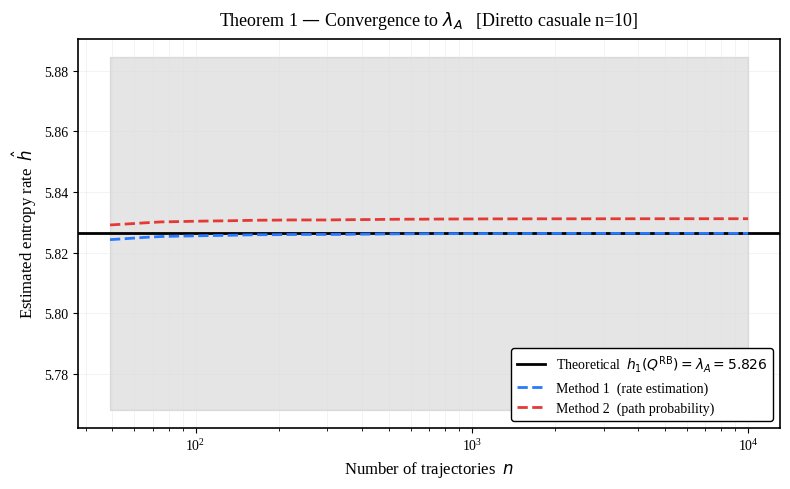

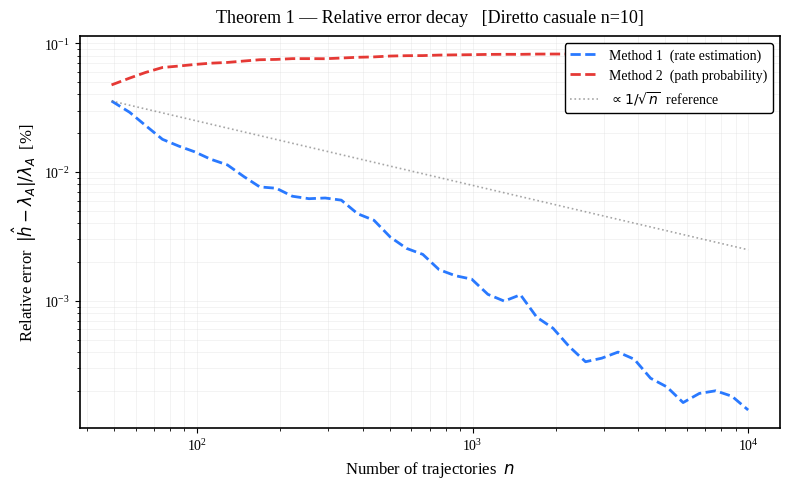


Final values:
  Method 1: 5.826374  (err 0.000%)
  Method 2: 5.831210  (err 0.083%)
  λ_A:      5.826383


In [ ]:
# ── TEOREMA 1: Visualizzazione convergenza Metodo 1 e Metodo 2 ───────────────
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from collections import defaultdict
from tqdm import tqdm

# ── Palette e stile ───────────────────────────────────────────────────────────
C_TH  = "#000000"
C_M1  = "#2979FF"
C_M2  = "#E53935"
BG    = "white"
GRID  = "#DDDDDD"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.edgecolor": "black", "axes.labelcolor": "black",
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "grid.color": GRID,
    "grid.linewidth": 0.6, "font.family": "Liberation Serif",
})

LABEL_KW  = dict(fontsize=12, fontfamily="Liberation Serif", color="black")
LEGEND_KW = dict(
    fontsize=10, facecolor="white", edgecolor="black", labelcolor="black",
    prop={"family": "Liberation Serif"}, framealpha=1.0, frameon=True,
)

# ── Checkpoints (scala log) ───────────────────────────────────────────────────
n_total      = len(trajectories)
n_checkpoints = 40
n_arr = np.unique(np.logspace(np.log10(50), np.log10(n_total),
                               n_checkpoints).astype(int))

# ── Calcolo curve di convergenza ──────────────────────────────────────────────
def h_method1_subset(trajs, waits, g, n):
    transition_counts    = defaultdict(int)
    total_time_per_state = defaultdict(float)
    for traj, wt in zip(trajs[:n], waits[:n]):
        for k in range(len(wt)):
            i, j = traj[k], traj[k+1]
            transition_counts[(i, j)] += 1
            total_time_per_state[i]   += wt[k]
    q_hat = {(i,j): c / total_time_per_state[i]
             for (i,j), c in transition_counts.items()
             if total_time_per_state[i] > 0}
    q_exit = defaultdict(float)
    for (i,j), r in q_hat.items():
        q_exit[i] += r
    total_time   = sum(total_time_per_state.values())
    pi_hat = {i: t / total_time for i, t in total_time_per_state.items()}
    h = 0.0
    for i in range(g.n):
        if i not in pi_hat:
            continue
        h += pi_hat[i] * q_exit[i]
        for j in range(g.n):
            if j != i and (i,j) in q_hat and q_hat[(i,j)] > 0:
                h += -pi_hat[i] * q_hat[(i,j)] * np.log(q_hat[(i,j)])
    return h

def h_method2_subset(trajs, waits, g, n):
    transition_counts    = defaultdict(int)
    total_time_per_state = defaultdict(float)
    for traj, wt in zip(trajs[:n], waits[:n]):
        for k in range(len(wt)):
            i, j = traj[k], traj[k+1]
            transition_counts[(i, j)] += 1
            total_time_per_state[i]   += wt[k]
    q_hat = {(i,j): c / total_time_per_state[i]
             for (i,j), c in transition_counts.items()
             if total_time_per_state[i] > 0}
    q_exit = defaultdict(float)
    for (i,j), r in q_hat.items():
        q_exit[i] += r
    total_time = sum(total_time_per_state.values())
    pi_hat = {i: t / total_time for i, t in total_time_per_state.items()}
    log_probs, durations = [], []
    for traj, wt in zip(trajs[:n], waits[:n]):
        if len(wt) == 0:
            continue
        x0 = traj[0]
        if x0 not in pi_hat or pi_hat[x0] == 0:
            continue
        log_p = np.log(pi_hat[x0])
        ok = True
        for k in range(len(wt)):
            i, j, tau = traj[k], traj[k+1], wt[k]
            q_ij = q_hat.get((i,j), 0.0)
            if q_ij == 0:
                ok = False; break
            log_p += np.log(q_ij) - q_exit[i] * tau
        if ok:
            log_probs.append(log_p)
            durations.append(sum(wt))
    return -np.mean(log_probs) / np.mean(durations)

print(f"Computing convergence curves over {len(n_arr)} checkpoints...")
h1_curve, h2_curve = [], []
for n in tqdm(n_arr):
    h1_curve.append(h_method1_subset(trajectories, waiting_times_per_traj, g, n))
    h2_curve.append(h_method2_subset(trajectories, waiting_times_per_traj, g, n))

h1_curve = np.array(h1_curve)
h2_curve = np.array(h2_curve)

# ── Salva curve su Drive ──────────────────────────────────────────────────────
SAVE_DIR = '/content/drive/MyDrive/ruelle_bowen_results'
os.makedirs(SAVE_DIR, exist_ok=True)
conv_path = os.path.join(SAVE_DIR, 'convergence_curves.pkl')
with open(conv_path, 'wb') as f:
    pickle.dump({
        'h1_curve': h1_curve, 'h2_curve': h2_curve,
        'n_arr': n_arr, 'h_theoretical': h_theoretical,
        'n_total': n_total,
    }, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"✓ Curve salvate in: {conv_path}")

# ── Figura 1: convergenza delle stime ────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5), facecolor=BG)
ax1.set_facecolor(BG)
for spine in ax1.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(1.2)

ax1.fill_between(n_arr, h_theoretical * 0.99, h_theoretical * 1.01,
                 alpha=0.10, color=C_TH, zorder=1)
ax1.axhline(h_theoretical, color=C_TH, lw=2, linestyle='-', zorder=2,
            label=f'Theoretical  $h_1(Q^{{\\mathrm{{RB}}}}) = \\lambda_A = {h_theoretical:.3f}$')
ax1.plot(n_arr, h1_curve, color=C_M1, lw=2.0, zorder=3, linestyle='--',
         label='Method 1  (rate estimation)')
ax1.plot(n_arr, h2_curve, color=C_M2, lw=2.0, zorder=3, linestyle='--',
         label='Method 2  (path probability)')

ax1.set_xscale('log')
ax1.set_xlabel('Number of trajectories  $n$', **LABEL_KW)
ax1.set_ylabel('Estimated entropy rate  $\\hat{h}$', **LABEL_KW)
ax1.legend(**LEGEND_KW, loc='lower right')
ax1.grid(True, which='both', alpha=0.4)
ax1.tick_params(colors='black')
ax1.set_title(f'Theorem 1 — Convergence to $\\lambda_A$   [{g.name}]',
              fontsize=13, fontfamily="Liberation Serif", pad=10)

plt.tight_layout()
fig1.savefig('/content/drive/MyDrive/ruelle_bowen_results/fig_theorem1_convergence.pdf',
             dpi=150, bbox_inches='tight', facecolor=BG, pad_inches=0.05)
fig1.savefig('/content/drive/MyDrive/ruelle_bowen_results/fig_theorem1_convergence.png',
             dpi=150, bbox_inches='tight', facecolor=BG, pad_inches=0.05)
plt.show()

# ── Figura 2: errore relativo ─────────────────────────────────────────────────
err1 = np.abs(h1_curve - h_theoretical) / h_theoretical * 100
err2 = np.abs(h2_curve - h_theoretical) / h_theoretical * 100

fig2, ax2 = plt.subplots(figsize=(8, 5), facecolor=BG)
ax2.set_facecolor(BG)
for spine in ax2.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(1.2)

ax2.plot(n_arr, err1, color=C_M1, lw=2.0, linestyle='--',
         label='Method 1  (rate estimation)')
ax2.plot(n_arr, err2, color=C_M2, lw=2.0, linestyle='--',
         label='Method 2  (path probability)')

# riferimento 1/sqrt(n)
ref = err1[0] * np.sqrt(n_arr[0]) / np.sqrt(n_arr)
ax2.plot(n_arr, ref, color='gray', lw=1.2, linestyle=':', alpha=0.7,
         label=r'$\propto 1/\sqrt{n}$  reference')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of trajectories  $n$', **LABEL_KW)
ax2.set_ylabel('Relative error  $|\\hat{h} - \\lambda_A| / \\lambda_A$  [%]', **LABEL_KW)
ax2.legend(**LEGEND_KW, loc='upper right')
ax2.grid(True, which='both', alpha=0.4)
ax2.tick_params(colors='black')
ax2.set_title(f'Theorem 1 — Relative error decay   [{g.name}]',
              fontsize=13, fontfamily="Liberation Serif", pad=10)

plt.tight_layout()
fig2.savefig('/content/drive/MyDrive/ruelle_bowen_results/fig_theorem1_error.pdf',
             dpi=150, bbox_inches='tight', facecolor=BG, pad_inches=0.05)
fig2.savefig('/content/drive/MyDrive/ruelle_bowen_results/fig_theorem1_error.png',
             dpi=150, bbox_inches='tight', facecolor=BG, pad_inches=0.05)
plt.show()

print(f"\nFinal values:")
print(f"  Method 1: {h1_curve[-1]:.6f}  (err {err1[-1]:.3f}%)")
print(f"  Method 2: {h2_curve[-1]:.6f}  (err {err2[-1]:.3f}%)")
print(f"  λ_A:      {h_theoretical:.6f}")

salvo convergenze su drive

In [ ]:
# ── Salva curve di convergenza su Google Drive ────────────────────────────────
import pickle
import os
from google.colab import drive

drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/ruelle_bowen_results'
os.makedirs(SAVE_DIR, exist_ok=True)

conv_path = os.path.join(SAVE_DIR, 'convergence_curves.pkl')
with open(conv_path, 'wb') as f:
    pickle.dump({
        'h1_curve':      h1_curve,
        'h2_curve':      h2_curve,
        'n_arr':         n_arr,
        'h_theoretical': h_theoretical,
        'n_total':       n_total,
        'graph_name':    g.name,
        'lambda_A':      g.lambda_A,
    }, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"✓ Salvato in: {conv_path}")
print(f"  Checkpoints: {len(n_arr)}")
print(f"  N_max:       {n_total:,}")
print(f"  Grafo:       {g.name}  (λ_A={g.lambda_A:.4f})")
print(f"  Dimensione:  {os.path.getsize(conv_path) / 1e3:.1f} KB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Salvato in: /content/drive/MyDrive/ruelle_bowen_results/convergence_curves.pkl
  Checkpoints: 40
  N_max:       10,000
  Grafo:       Diretto casuale n=10  (λ_A=5.8264)
  Dimensione:  1.3 KB


carico convergenze da drive

In [ ]:
# ── Carica curve di convergenza da Google Drive ───────────────────────────────
import pickle
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

conv_path = '/content/drive/MyDrive/ruelle_bowen_results/convergence_curves.pkl'
with open(conv_path, 'rb') as f:
    conv = pickle.load(f)

h1_curve      = conv['h1_curve']
h2_curve      = conv['h2_curve']
n_arr         = conv['n_arr']
h_theoretical = conv['h_theoretical']
n_total       = conv['n_total']

print(f"✓ Caricato: {conv_path}")
print(f"  Grafo:       {conv['graph_name']}  (λ_A={conv['lambda_A']:.4f})")
print(f"  Checkpoints: {len(n_arr)}")
print(f"  N_max:       {n_total:,}")
print(f"\n  Method 1 final: {h1_curve[-1]:.6f}  "
      f"(err {abs(h1_curve[-1]-h_theoretical)/h_theoretical*100:.3f}%)")
print(f"  Method 2 final: {h2_curve[-1]:.6f}  "
      f"(err {abs(h2_curve[-1]-h_theoretical)/h_theoretical*100:.3f}%)")
print(f"  λ_A (theory):   {h_theoretical:.6f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Caricato: /content/drive/MyDrive/ruelle_bowen_results/convergence_curves.pkl
  Grafo:       Diretto casuale n=10  (λ_A=5.8264)
  Checkpoints: 40
  N_max:       10,000

  Method 1 final: 5.826374  (err 0.000%)
  Method 2 final: 5.831210  (err 0.083%)
  λ_A (theory):   5.826383


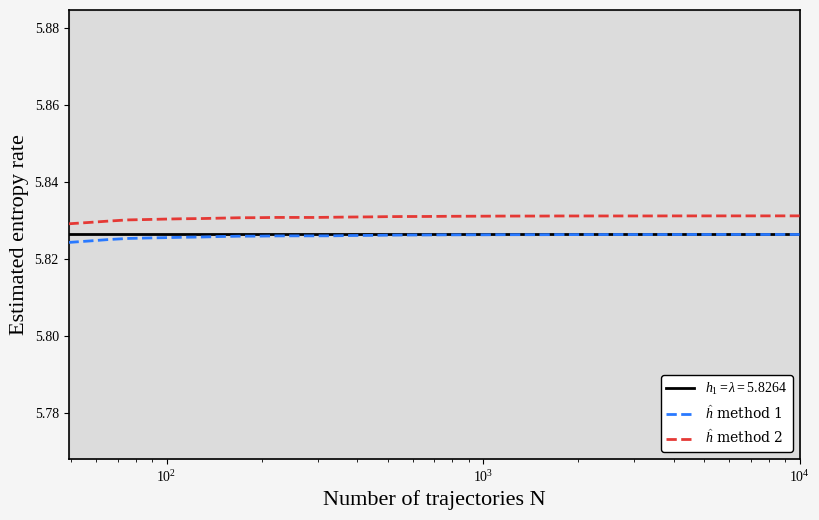

In [ ]:
# ── TEOREMA 1: Visualizzazione convergenza ────────────────────────────────────
import matplotlib.pyplot as plt
import os

C_TH  = "#000000"
C_M1  = "#2979FF"
C_M2  = "#E53935"
BG    = "white"
GRID  = "#DDDDDD"
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Liberation Serif"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Liberation Serif",
    "mathtext.it": "Liberation Serif:italic",
    "mathtext.bf": "Liberation Serif:bold",
})

LABEL_KW  = dict(fontsize=16, fontfamily="Liberation Serif", color="black")
LEGEND_KW = dict(
    fontsize=10, facecolor="white", edgecolor="black", labelcolor="black",
    prop={"family": "DejaVu Serif"}, framealpha=1.0, frameon=True,
)

SAVE_DIR = '/content/drive/MyDrive/ruelle_bowen_results'

# ── Figura 1: convergenza ─────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5), facecolor='#F5F5F5')
ax1.set_facecolor('#F5F5F5')
for spine in ax1.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(1.2)

ax1.fill_between(n_arr, h_theoretical * 0.99, h_theoretical * 1.01,
                 alpha=0.10, color=C_TH, zorder=1)
ax1.axhline(h_theoretical, color=C_TH, lw=2, linestyle='-', zorder=2,
            label=f'$h_1 = \\lambda = {h_theoretical:.4f}$')
ax1.plot(n_arr, h1_curve, color=C_M1, lw=2.0, linestyle='--', zorder=3,
         label='$\hat{h}$ method 1')
ax1.plot(n_arr, h2_curve, color=C_M2, lw=2.0, linestyle='--', zorder=3,
         label='$\hat{h}$ method 2')

ax1.set_xscale('log')
ax1.set_xlabel('Number of trajectories N', **LABEL_KW)
ax1.set_ylabel('Estimated entropy rate', **LABEL_KW)
ax1.legend(**LEGEND_KW, loc='lower right')
ax1.grid(True, which='both', alpha=0.4)
ax1.tick_params(colors='black')

# Rimuove i margini bianchi
ax1.margins(0)  # rimuove il margine automatico su tutti gli assi
ax1.set_xlim(n_arr[0], n_arr[-1])
plt.tight_layout(pad=0)

for ext in ('pdf', 'png'):
    fig1.savefig(os.path.join(SAVE_DIR, f'fig_theorem1_convergence.{ext}'),
                 dpi=150, bbox_inches='tight', facecolor='#F5F5F5', pad_inches=0)
plt.show()

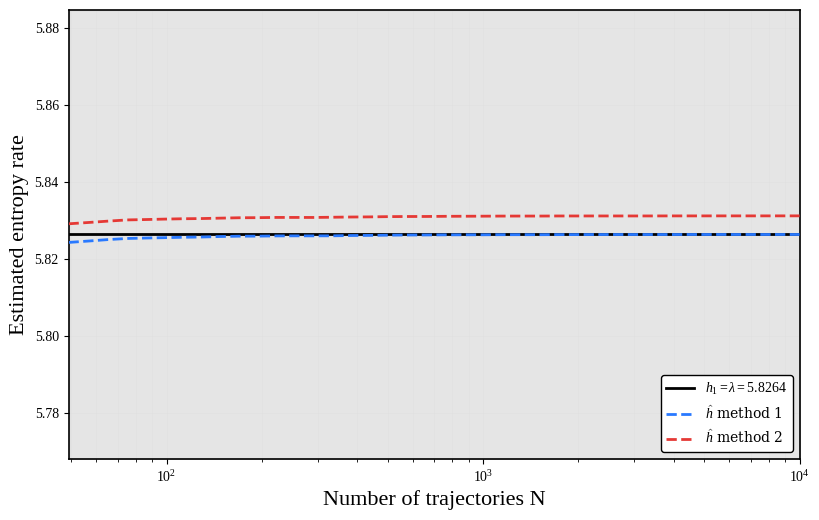

In [ ]:
# ── TEOREMA 1: Visualizzazione convergenza ────────────────────────────────────
import matplotlib.pyplot as plt
import os

C_TH  = "#000000"
C_M1  = "#2979FF"
C_M2  = "#E53935"
BG    = "#FFFFFF"
GRID  = "#DDDDDD"
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Liberation Serif"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Liberation Serif",
    "mathtext.it": "Liberation Serif:italic",
    "mathtext.bf": "Liberation Serif:bold",
})

LABEL_KW  = dict(fontsize=16, fontfamily="Liberation Serif", color="black")
LEGEND_KW = dict(
    fontsize=10, facecolor="white", edgecolor="black", labelcolor="black",
    prop={"family": "DejaVu Serif"}, framealpha=1.0, frameon=True,
)

SAVE_DIR = '/content/drive/MyDrive/ruelle_bowen_results'

# ── Figura 1: convergenza ─────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))
fig1.patch.set_facecolor(BG)
ax1.patch.set_facecolor(BG)
for spine in ax1.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(1.2)

ax1.fill_between(n_arr, h_theoretical * 0.99, h_theoretical * 1.01,
                 alpha=0.10, color=C_TH, zorder=1)
ax1.axhline(h_theoretical, color=C_TH, lw=2, linestyle='-', zorder=2,
            label=f'$h_1 = \\lambda = {h_theoretical:.4f}$')
ax1.plot(n_arr, h1_curve, color=C_M1, lw=2.0, linestyle='--', zorder=3,
         label='$\hat{h}$ method 1')
ax1.plot(n_arr, h2_curve, color=C_M2, lw=2.0, linestyle='--', zorder=3,
         label='$\hat{h}$ method 2')

ax1.set_xscale('log')
ax1.set_xlabel('Number of trajectories N', **LABEL_KW)
ax1.set_ylabel('Estimated entropy rate', **LABEL_KW)
ax1.legend(**LEGEND_KW, loc='lower right')
ax1.grid(True, which='both', alpha=0.4, color=GRID)
ax1.tick_params(colors='black')

ax1.margins(0)
ax1.set_xlim(n_arr[0], n_arr[-1])
plt.tight_layout(pad=0)

for ext in ('pdf', 'png'):
    fig1.savefig(os.path.join(SAVE_DIR, f'fig_theorem1_convergence.{ext}'),
                 dpi=150, bbox_inches='tight', facecolor=BG, pad_inches=0)
plt.show()

## Genero traiettorie con T=500/$\lambda$

In [ ]:
# ── TEOREMA 1: Generazione traiettorie continue ─────────────────────────────
from collections import defaultdict
from tqdm import tqdm
import numpy as np

def generate_ct_trajectory(g, T):
    """
    Genera una traiettoria del processo di Markov a tempo continuo con
    generatore Q_RB, fino al tempo T.
    Restituisce: (sequenza di nodi, tempi di attesa)
    """
    n = g.n
    Q = g.Q_RB
    # Exit rates per ogni nodo: q_i = -Q[i,i]
    exit_rates = -np.diag(Q)
    # Transition probs: pi_{ij} = Q[i,j] / q_i  (per j != i)
    trans_probs = np.zeros((n, n))
    for i in range(n):
        if exit_rates[i] > 0:
            for j in range(n):
                if j != i:
                    trans_probs[i, j] = Q[i, j] / exit_rates[i]

    # Nodo iniziale campionato dalla stazionaria pi_RB
    current = np.random.choice(n, p=g.pi_RB / g.pi_RB.sum())
    traj = [current]
    waits = []
    t = 0.0

    while True:
        rate = exit_rates[current]
        tau  = np.random.exponential(1.0 / rate)
        if t + tau > T:
            break
        t += tau
        waits.append(tau)
        next_node = np.random.choice(n, p=trans_probs[current])
        traj.append(next_node)
        current = next_node

    return traj, waits

# ── Parametri ───────────────────────────────────────────────────────────────
g = G_rand   # grafo diretto casuale

n_trajectories = 10_000
T_per_traj     = 500 / g.lambda_A   # ~3500 salti attesi

print(f"Grafo: {g.name}  (n={g.n}, λ_A={g.lambda_A:.4f})")
print(f"Generating {n_trajectories} trajectories with T = {T_per_traj:.4f} each...")
print(f"Expected jumps per trajectory: ~{T_per_traj * g.lambda_A:.0f}")

trajectories         = []
waiting_times_per_traj = []
all_waiting_times    = []
n_steps_list         = []

for _ in tqdm(range(n_trajectories)):
    traj, waits = generate_ct_trajectory(g, T_per_traj)
    trajectories.append(traj)
    waiting_times_per_traj.append(waits)
    all_waiting_times.extend(waits)
    n_steps_list.append(len(waits))

all_waiting_times = np.array(all_waiting_times)
n_steps_list      = np.array(n_steps_list)

print(f"\nGeneration complete!")
print(f"Total transitions:          {len(all_waiting_times):,}")
print(f"Mean steps per trajectory:  {np.mean(n_steps_list):.1f}  (expected ~3500)")
print(f"Std  steps per trajectory:  {np.std(n_steps_list):.1f}")
print(f"Mean waiting time:          {np.mean(all_waiting_times):.6f}")
print(f"Expected (1/λ_A):           {1.0/g.lambda_A:.6f}")
print(f"Relative error:             {abs(np.mean(all_waiting_times) - 1/g.lambda_A) / (1/g.lambda_A) * 100:.2f}%")

Grafo: Diretto casuale n=10  (n=20, λ_A=5.8264)
Generating 10000 trajectories with T = 85.8165 each...
Expected jumps per trajectory: ~500


100%|██████████| 10000/10000 [01:56<00:00, 85.74it/s]



Generation complete!
Total transitions:          5,000,849
Mean steps per trajectory:  500.1  (expected ~3500)
Std  steps per trajectory:  22.3
Mean waiting time:          0.171268
Expected (1/λ_A):           0.171633
Relative error:             0.21%


salvo traiettorie

In [ ]:
# ── SALVATAGGIO TRAIETTORIE SU GOOGLE DRIVE ─────────────────────────────────
import pickle
import os

# Monta Drive se non già montato
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Percorso di salvataggio
save_dir = '/content/drive/MyDrive/markov_trajectories'
os.makedirs(save_dir, exist_ok=True)

pkl_filename = f'trajectories_T500_lambdaA_{g.lambda_A:.6f}_{g.name}.pkl'
pkl_path = os.path.join(save_dir, pkl_filename)

data_to_save = {
    'graph_name':              g.name,
    'n_nodes':                 g.n,
    'lambda_A':                g.lambda_A,
    'T_multiplier':            500,          # T = 500 / lambda_A
    'T_per_traj':              T_per_traj,
    'n_trajectories':          n_trajectories,
    'trajectories':            trajectories,
    'waiting_times_per_traj':  waiting_times_per_traj,
    'all_waiting_times':       all_waiting_times,
    'n_steps_list':            n_steps_list,
}

with open(pkl_path, 'wb') as f:
    pickle.dump(data_to_save, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Salvato: {pkl_path}")
print(f"Dimensione file: {os.path.getsize(pkl_path) / 1e6:.2f} MB")

Mounted at /content/drive
Salvato: /content/drive/MyDrive/markov_trajectories/trajectories_T500_lambdaA_5.826383_Diretto casuale n=10.pkl
Dimensione file: 95.20 MB


carico traiettorie salvate

In [ ]:
# ── CARICAMENTO TRAIETTORIE DA GOOGLE DRIVE ──────────────────────────────────
import pickle
import numpy as np
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Adatta nome grafo e lambda_A se necessario
graph_name = G_rand.name
lambda_A   = G_rand.lambda_A

pkl_path = f'/content/drive/MyDrive/markov_trajectories/trajectories_T500_lambdaA_{lambda_A:.6f}_{graph_name}.pkl'

with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

trajectories            = data['trajectories']
waiting_times_per_traj  = data['waiting_times_per_traj']
all_waiting_times       = data['all_waiting_times']
n_steps_list            = data['n_steps_list']
T_per_traj              = data['T_per_traj']
n_trajectories          = data['n_trajectories']

print(f"Caricato: {pkl_path}")
print(f"Grafo: {data['graph_name']}  |  λ_A = {data['lambda_A']:.6f}")
print(f"T = {data['T_multiplier']} / λ_A = {T_per_traj:.4f}")
print(f"Traiettorie: {n_trajectories:,}  |  Transizioni totali: {len(all_waiting_times):,}")
print(f"Passi medi per traiettoria: {np.mean(n_steps_list):.1f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Caricato: /content/drive/MyDrive/markov_trajectories/trajectories_T500_lambdaA_5.826383_Diretto casuale n=10.pkl
Grafo: Diretto casuale n=10  |  λ_A = 5.826383
T = 500 / λ_A = 85.8165
Traiettorie: 10,000  |  Transizioni totali: 5,000,849
Passi medi per traiettoria: 500.1


## Metodo 1 di verifica

In [ ]:
# ── TEOREMA 1: Verifica — Metodo 1 (stima diretta dei rate) ─────────────────
import pickle
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── Caricamento PKL T=500 ────────────────────────────────────────────────────
g = G_rand
pkl_path = f'/content/drive/MyDrive/markov_trajectories/trajectories_T500_lambdaA_{g.lambda_A:.6f}_{g.name}.pkl'

with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

trajectories           = data['trajectories']
waiting_times_per_traj = data['waiting_times_per_traj']

print(f"PKL caricato: {pkl_path}")
print(f"Traiettorie: {data['n_trajectories']:,}  |  T = {data['T_multiplier']} / λ_A\n")

# ── Funzioni ─────────────────────────────────────────────────────────────────
def compute_differential_entropy_rate_theoretical(Q, pi):
    """h_1(Q^RB) = -Σ_i π_i q_ii - Σ_{i≠j} π_i q_ij log(q_ij)"""
    h = 0.0
    n = len(pi)
    for i in range(n):
        h += -pi[i] * Q[i, i]
        for j in range(n):
            if j != i and Q[i, j] > 0:
                h += -pi[i] * Q[i, j] * np.log(Q[i, j])
    return h

def compute_entropy_rate_empirical_method1(trajectories, waiting_times_list, g):
    """
    Stima l'entropy rate da traiettorie:
      1. Stima i rate q_{ij} = #(i→j) / tempo_totale_in_i
      2. Stima π_i = tempo_in_i / tempo_totale
      3. Applica la formula h_1(Q)
    """
    transition_counts    = defaultdict(int)
    total_time_per_state = defaultdict(float)

    for traj, waits in zip(trajectories, waiting_times_list):
        for k in range(len(waits)):
            i = traj[k]
            j = traj[k + 1]
            transition_counts[(i, j)] += 1
            total_time_per_state[i]   += waits[k]

    # Rate stimati: q_hat_{ij} = count(i→j) / T_i
    estimated_rates = {}
    for (i, j), count in transition_counts.items():
        if total_time_per_state[i] > 0:
            estimated_rates[(i, j)] = count / total_time_per_state[i]

    # Misura stazionaria empirica
    total_time   = sum(total_time_per_state.values())
    pi_empirical = {i: t / total_time for i, t in total_time_per_state.items()}

    # Calcolo h empirico con la formula del paper (eq. 2, η=1)
    h = 0.0
    for i in range(g.n):
        if i not in pi_empirical:
            continue
        pi_i = pi_empirical[i]
        q_exit = sum(estimated_rates.get((i, j), 0) for j in range(g.n) if j != i)
        h += pi_i * q_exit
        for j in range(g.n):
            if j != i and (i, j) in estimated_rates:
                q_ij = estimated_rates[(i, j)]
                if q_ij > 0:
                    h += -pi_i * q_ij * np.log(q_ij)

    return h, pi_empirical, estimated_rates

# ── Calcoli ──────────────────────────────────────────────────────────────────
h_theoretical = compute_differential_entropy_rate_theoretical(g.Q_RB, g.pi_RB)

print("=" * 60)
print("THEOREM 1 VERIFICATION — METHOD 1 (direct rate estimation)")
print("=" * 60)
print(f"\nGraph: {g.name}  (n={g.n})")
print(f"\nTheoretical h_1(Q^RB) : {h_theoretical:.6f}")
print(f"Expected (λ_A)        : {g.lambda_A:.6f}")
print(f"Match?                : {np.isclose(h_theoretical, g.lambda_A, rtol=1e-5)}")
print(f"Relative error        : {abs(h_theoretical - g.lambda_A) / g.lambda_A * 100:.6f}%")

print(f"\nComputing empirical entropy rate from {len(trajectories):,} trajectories...")
h_empirical, pi_emp, rates_emp = compute_entropy_rate_empirical_method1(
    trajectories, waiting_times_per_traj, g
)

print(f"\nEmpirical h (Method 1) : {h_empirical:.6f}")
print(f"Theoretical h_1(Q^RB) : {h_theoretical:.6f}")
print(f"λ_A                   : {g.lambda_A:.6f}")
print(f"Relative error (vs h) : {abs(h_empirical - h_theoretical) / h_theoretical * 100:.4g}%")
print(f"Relative error (vs λ) : {abs(h_empirical - g.lambda_A)    / g.lambda_A    * 100:.4g}%")

# Confronto π empirica vs teorica
print(f"\nStationary distribution check (first 5 nodes):")
print(f"  {'node':>5}  {'π_theoretical':>14}  {'π_empirical':>12}  {'rel_err':>9}")
for i in range(min(5, g.n)):
    pi_th = g.pi_RB[i]
    pi_em = pi_emp.get(i, 0.0)
    err   = abs(pi_th - pi_em) / pi_th * 100 if pi_th > 0 else float('nan')
    print(f"  {i:>5}  {pi_th:>14.6f}  {pi_em:>12.6f}  {err:>8.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PKL caricato: /content/drive/MyDrive/markov_trajectories/trajectories_T500_lambdaA_5.826383_Diretto casuale n=10.pkl
Traiettorie: 10,000  |  T = 500 / λ_A

THEOREM 1 VERIFICATION — METHOD 1 (direct rate estimation)

Graph: Diretto casuale n=10  (n=20)

Theoretical h_1(Q^RB) : 5.826383
Expected (λ_A)        : 5.826383
Match?                : True
Relative error        : 0.000000%

Computing empirical entropy rate from 10,000 trajectories...

Empirical h (Method 1) : 5.826314
Theoretical h_1(Q^RB) : 5.826383
λ_A                   : 5.826383
Relative error (vs h) : 0.001187%
Relative error (vs λ) : 0.001187%

Stationary distribution check (first 5 nodes):
   node   π_theoretical   π_empirical    rel_err
      0        0.045641      0.045646      0.01%
      1        0.080035      0.080020      0.02%
      2        0.014029      0.014041      0.09%
      3       

## Metodo 2 di verifica

In [ ]:
# ── TEOREMA 1: Verifica — Metodo 2 (path probability / cross-entropy) ────────
import pickle
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── Caricamento PKL T=500 ────────────────────────────────────────────────────
g = G_rand
pkl_path = f'/content/drive/MyDrive/markov_trajectories/trajectories_T500_lambdaA_{g.lambda_A:.6f}_{g.name}.pkl'

with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

trajectories           = data['trajectories']
waiting_times_per_traj = data['waiting_times_per_traj']

print(f"✓ Caricato: {pkl_path}")
print(f"  Traiettorie : {data['n_trajectories']:,}  |  T = {data['T_multiplier']} / λ_A\n")

# ── Funzione ─────────────────────────────────────────────────────────────────
def compute_entropy_rate_path_prob_method2(trajectories, waiting_times_list, g):
    """
    Stima l'entropy rate come:
      h ≈ -E[log P(traiettoria)] / E[durata]
    dove log P(traiettoria) è calcolato usando i rate stimati q_hat.
    """
    transition_counts    = defaultdict(int)
    total_time_per_state = defaultdict(float)

    for traj, waits in zip(trajectories, waiting_times_list):
        for k in range(len(waits)):
            i = traj[k]
            j = traj[k + 1]
            transition_counts[(i, j)] += 1
            total_time_per_state[i]   += waits[k]

    q_hat = {}
    for (i, j), count in transition_counts.items():
        if total_time_per_state[i] > 0:
            q_hat[(i, j)] = count / total_time_per_state[i]

    q_hat_exit = defaultdict(float)
    for (i, j), rate in q_hat.items():
        q_hat_exit[i] += rate

    total_time = sum(total_time_per_state.values())
    pi_hat     = {i: t / total_time for i, t in total_time_per_state.items()}

    log_probs = []
    durations = []

    for traj, waits in zip(trajectories, waiting_times_list):
        if len(waits) == 0:
            continue
        x0 = traj[0]
        if x0 not in pi_hat or pi_hat[x0] == 0:
            continue

        log_p = np.log(pi_hat[x0])
        ok    = True

        for k in range(len(waits)):
            i    = traj[k]
            j    = traj[k + 1]
            tau  = waits[k]
            q_ij = q_hat.get((i, j), 0.0)
            if q_ij == 0:
                ok = False
                break
            log_p += np.log(q_ij) - q_hat_exit[i] * tau

        if ok:
            log_probs.append(log_p)
            durations.append(sum(waits))

    h_estimate = -np.mean(log_probs) / np.mean(durations)
    return h_estimate

# ── Calcoli ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("THEOREM 1 VERIFICATION — METHOD 2 (path probability)")
print("=" * 60)
print(f"\nGraph: {g.name}  (n={g.n})")
print(f"\nComputing empirical entropy rate from {len(trajectories):,} trajectories...")

h_empirical_two = compute_entropy_rate_path_prob_method2(
    trajectories, waiting_times_per_traj, g
)

print(f"\nEmpirical h (Method 2)  : {h_empirical_two:.6f}")
print(f"Theoretical h_1(Q^RB)   : {h_theoretical:.6f}")
print(f"λ_A                     : {g.lambda_A:.6f}")
print(f"Relative error (vs h)   : {abs(h_empirical_two - h_theoretical) / h_theoretical * 100:.4g}%")
print(f"Relative error (vs λ_A) : {abs(h_empirical_two - g.lambda_A)    / g.lambda_A    * 100:.4g}%")

# ── Riepilogo comparativo ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  λ_A  (teoria)       : {g.lambda_A:.6f}")
print(f"  h_1(Q^RB) (teoria)  : {h_theoretical:.6f}  (match: {np.isclose(h_theoretical, g.lambda_A, rtol=1e-5)})")
print(f"  h empirica M1       : {h_empirical:.6f}  (err: {abs(h_empirical     - g.lambda_A) / g.lambda_A * 100:.4g}%)")
print(f"  h empirica M2       : {h_empirical_two:.6f}  (err: {abs(h_empirical_two - g.lambda_A) / g.lambda_A * 100:.4g}%)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Caricato: /content/drive/MyDrive/markov_trajectories/trajectories_T500_lambdaA_5.826383_Diretto casuale n=10.pkl
  Traiettorie : 10,000  |  T = 500 / λ_A

THEOREM 1 VERIFICATION — METHOD 2 (path probability)

Graph: Diretto casuale n=10  (n=20)

Computing empirical entropy rate from 10,000 trajectories...

Empirical h (Method 2)  : 5.860188
Theoretical h_1(Q^RB)   : 5.826383
λ_A                     : 5.826383
Relative error (vs h)   : 0.5802%
Relative error (vs λ_A) : 0.5802%

SUMMARY
  λ_A  (teoria)       : 5.826383
  h_1(Q^RB) (teoria)  : 5.826383  (match: True)
  h empirica M1       : 5.826374  (err: 0.0001419%)
  h empirica M2       : 5.860188  (err: 0.5802%)
